# Phase 1 optimizer -- post-hoc smoothing (Section 12.2)

This is one of 7 notebooks in `notebooks/phase1_optimization/`.
Equation/section citations here follow `docs/tt pacing optimizer.md`, the
project's canonical numbering, written as "(design-doc Eq. N)" /
"(design-doc Section N.M)"; display-unit conventions (km/min/km-h⁻¹) are
implemented in `phase_1_0_common.py`'s `as_km`/`as_min`/`as_kmh` helpers, shared
by all 7 notebooks. This one covers
**smooth_posthoc's cheap box-filter-then-resimulate diagnostic mode, stress-tested across the same 6 input-quality tiers as the constrained-re-optimization notebook, plus a direct comparison of the two modes**.

It is fully self-contained: every rider/course/baseline it needs is
rebuilt here via `phase_1_0_common.py` (shared by all 7 split notebooks),
so it runs standalone from a fresh kernel without any other notebook
having run first. Courses used: flat, rolling (synthetic) + Giro10, TdF16, TARA (real). Approx. runtime: ~1.5 min (measured).

In [1]:
import sys
sys.path.insert(0, ".")
import phase_1_0_common as pc

pc.print_rider_summary()

reference_rider        mass= 72.0 kg  CP= 280.0 W  W'= 20.0 kJ  CdA=0.25 m^2  P_max=   900 W
evenepoel_like_rider   mass= 63.5 kg  CP= 425.0 W  W'= 20.0 kJ  CdA=0.21 m^2  P_max=  1400 W
ganna_like_rider       mass= 82.0 kg  CP= 480.0 W  W'= 20.0 kJ  CdA=0.19 m^2  P_max=  1600 W


In [2]:
courses = pc.load_real_courses()
giro10_course, tdf16_course, tara_course = courses["giro10"], courses["tdf16"], courses["tara"]
pc.print_real_course_summary(courses)

Giro 2026 Stage 10   n_nodes= 800  smoothing_length_m=  150 m  mean|grade|= 0.34%  max|grade|= 2.05%
TdF 2026 Stage 16    n_nodes= 800  smoothing_length_m=  400 m  mean|grade|= 3.37%  max|grade|= 7.59%
TARA 2026 Stage 3    n_nodes= 800  smoothing_length_m=  250 m  mean|grade|= 2.42%  max|grade|= 6.22%


Rebuilding all 5 courses' Hermite-Simpson baselines (`build_hs_baseline`)
before the demonstration below -- cheap here since, unlike the
constrained-re-optimization notebook, nothing after this cell re-solves
an NLP.

In [3]:
flat_course = pc.build_flat_course()
rolling_course = pc.build_rolling_course()

opt_hs_flat, res_hs_flat = pc.build_hs_baseline(pc.reference_rider, flat_course, pc.calm_wind, pc.N_INTERVALS_BASIC)
opt_hs_rolling, res_hs_rolling = pc.build_hs_baseline(pc.reference_rider, rolling_course, pc.calm_wind, pc.N_INTERVALS_BASIC)
opt_hs_giro10, res_hs_giro10 = pc.build_hs_baseline(pc.ganna_like_rider, giro10_course, pc.calm_wind, pc.N_INTERVALS_GIRO10)
opt_hs_tdf16, res_hs_tdf16 = pc.build_hs_baseline(pc.evenepoel_like_rider, tdf16_course, pc.calm_wind, pc.N_INTERVALS_TDF16)
opt_hs_tara, res_hs_tara = pc.build_hs_baseline(pc.reference_rider, tara_course, pc.calm_wind, pc.N_INTERVALS_TARA)

## Post-hoc mode (design-doc Section 12.2)

`smooth_posthoc` (design-doc Section 12.2, diagnostic mode) takes a
completely different approach from Eq. 45: it does **not** re-optimize.
It box-filters (moving average, `window_nodes` wide) the unsmoothed
plan's `full_course_power_W` and re-simulates the filtered trace forward
with `ForwardSimulator`. It is cheap (one forward simulation, no NLP
solve) but the result is **not** claimed to be optimal, and -- because
nothing enforces $W'_{bal} \ge 0$ (design-doc Eqs. 31-32) during the filtering step --
it can genuinely violate that path constraint. That is by design: the
point of this mode is to reveal such violations cheaply, not to hide
them or to produce a rideable plan.

The same 6 quality tiers from the constrained-re-optimization notebook
are run through `smooth_posthoc` below, this time perturbing
`full_course_power_W` (the full-course grid, not the post-launch
collocation grid `smooth_constrained` uses).

### 5.1 Flat course

In [4]:
posthoc_results_flat = pc.run_posthoc_tiers(pc.reference_rider, flat_course, pc.calm_wind, res_hs_flat, catastrophic_mode="square", label="flat")

[flat] good         T= 57.0911 min  unsmoothed= 57.1178 min  delta= -1.599 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.583
[flat] acceptable   T= 57.1076 min  unsmoothed= 57.1178 min  delta= -0.615 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.285
[flat] borderline   T= 57.1314 min  unsmoothed= 57.1178 min  delta= +0.816 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.225
[flat] rough        T= 57.1352 min  unsmoothed= 57.1178 min  delta= +1.043 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.217
[flat] very_rough   T= 57.1065 min  unsmoothed= 57.1178 min  delta= -0.676 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.588
[flat] catastrophic T= 47.8591 min  unsmoothed= 57.1178 min  delta=-555.520 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.955


Every tier here shows `w_prime_violated=True`, including the mildest
(`good`). That is expected, not a bug in the perturbation design: the
flat-course optimal baseline already spends W' down to essentially zero
by the finish, by construction (the $W'_{bal} \ge 0$ path constraint,
design-doc Eqs. 31-32, binds exactly there, as `test_slsqp_terminal_w_prime_near_zero` checks) -- so it starts
with zero margin, and *any* re-filtering of it risks dipping into that
floor somewhere. Several tiers even show a **negative** time delta (the
filtered trace appears to finish *faster* than the true optimum). This is
not a real speed-up: it is `ForwardSimulator`'s RK4 integrator not
reducing deliverable power once $W'_{bal}$ is clamped at its floor (a
known approximation noted in `smoothing.py`'s own docstring), so a
`time_total_s` reported alongside `w_prime_violated=True` should not be
read as an achievable time. This is exactly why
`test_smoothing_posthoc_slower_or_flagged_infeasible` accepts
`time_total_s >= unsmoothed_time_total_s OR w_prime_violated` rather than
a strict inequality.

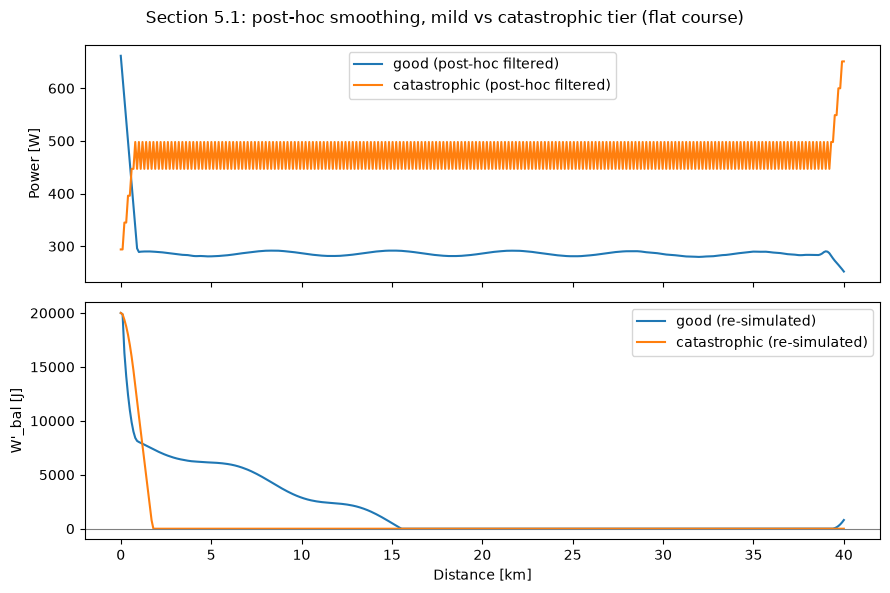

In [5]:
pc.plot_posthoc_extremes(res_hs_flat, flat_course, posthoc_results_flat, "Section 5.1: post-hoc smoothing, mild vs catastrophic tier (flat course)")

### 5.2 Rolling course

In [6]:
posthoc_results_rolling = pc.run_posthoc_tiers(pc.reference_rider, rolling_course, pc.calm_wind, res_hs_rolling, catastrophic_mode="sine", label="rolling")

[rolling] good         T= 34.0740 min  unsmoothed= 34.0745 min  delta= -0.030 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.167
[rolling] acceptable   T= 34.0755 min  unsmoothed= 34.0745 min  delta= +0.063 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.133
[rolling] borderline   T= 34.0735 min  unsmoothed= 34.0745 min  delta= -0.056 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.158
[rolling] rough        T= 34.0812 min  unsmoothed= 34.0745 min  delta= +0.402 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.133
[rolling] very_rough   T= 34.1024 min  unsmoothed= 34.0745 min  delta= +1.673 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.113
[rolling] catastrophic T= 34.0897 min  unsmoothed= 34.0745 min  delta= +0.915 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.154


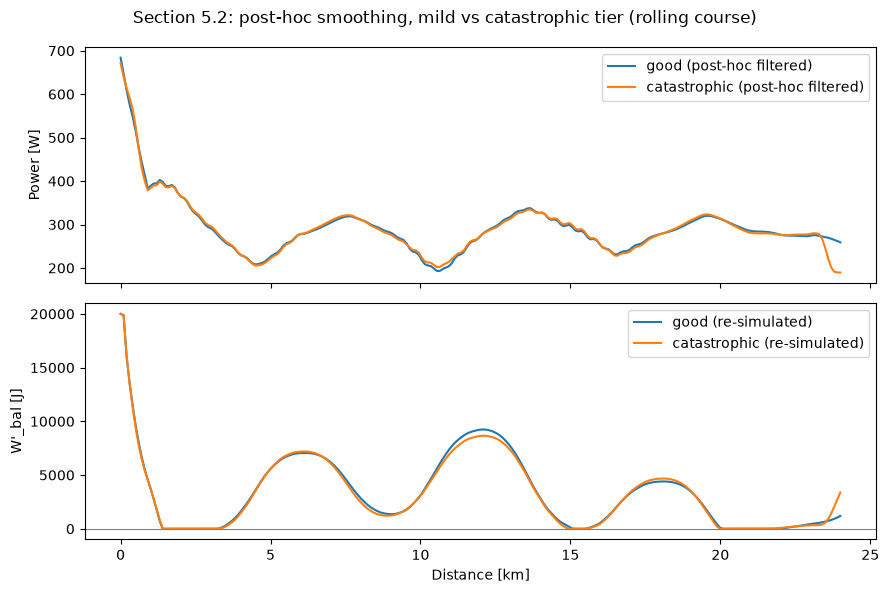

In [7]:
pc.plot_posthoc_extremes(res_hs_rolling, rolling_course, posthoc_results_rolling, "Section 5.2: post-hoc smoothing, mild vs catastrophic tier (rolling course)")

The same pattern holds: every tier's baseline already ends near-zero W',
so every tier flags a violation, and the reported times are not
trustworthy comparisons once that flag is set.

### Constrained re-optimization vs post-hoc smoothing, in one sentence

**Eq. 45 (design-doc Section 12.1, the constrained-re-optimization
notebook)** re-solves the NLP with the slew bound built in, so
$W'_{bal} \ge 0$ (design-doc Eqs. 31-32) is enforced throughout the
solve -- it always returns a genuinely rideable plan, at a time cost that
scales with how much correction the input trace actually needed.
**Design-doc Section 12.2 (this notebook)** only filters and
re-checks after the fact -- it is cheap and useful as a diagnostic ("how
bad would naive smoothing be here?"), but it can return a plan that
violates the rider's own physiology, and its reported time is not
trustworthy when it does.

### 5.3 Giro 2026 Stage 10 (real, flat)

Same 6 tiers as 5.1/5.2, on `res_hs_giro10` (rebuilt above), same
`catastrophic_mode` as the constrained-smoothing notebook's 4.3
(`"square"`).

In [8]:
posthoc_results_giro10 = pc.run_posthoc_tiers(pc.ganna_like_rider, giro10_course, pc.calm_wind, res_hs_giro10, catastrophic_mode="square", label="giro10")

[giro10] good         T= 43.2160 min  unsmoothed= 43.2630 min  delta= -2.816 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.066
[giro10] acceptable   T= 43.2397 min  unsmoothed= 43.2630 min  delta= -1.399 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.069
[giro10] borderline   T= 43.2589 min  unsmoothed= 43.2630 min  delta= -0.244 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.080
[giro10] rough        T= 43.3522 min  unsmoothed= 43.2630 min  delta= +5.351 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.113
[giro10] very_rough   T= 43.4584 min  unsmoothed= 43.2630 min  delta=+11.723 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.100
[giro10] catastrophic T= 35.8813 min  unsmoothed= 43.2630 min  delta=-442.904 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.971


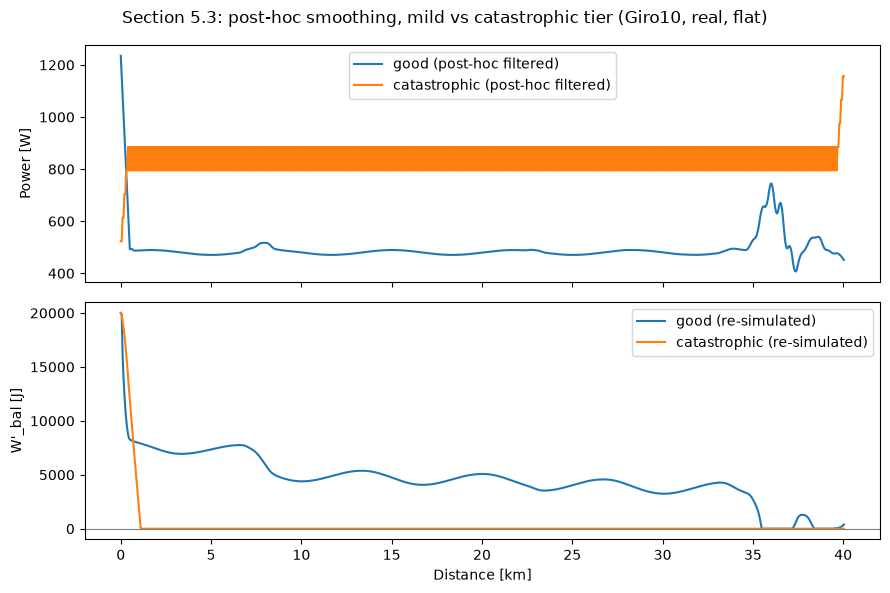

In [9]:
pc.plot_posthoc_extremes(res_hs_giro10, giro10_course, posthoc_results_giro10, "Section 5.3: post-hoc smoothing, mild vs catastrophic tier (Giro10, real, flat)")

### 5.4 TdF 2026 Stage 16 (real, mountainous)

Same 6 tiers, on `res_hs_tdf16` (rebuilt above), same `catastrophic_mode`
as 4.4 (`"sine"`).

In [10]:
posthoc_results_tdf16 = pc.run_posthoc_tiers(pc.evenepoel_like_rider, tdf16_course, pc.calm_wind, res_hs_tdf16, catastrophic_mode="sine", label="tdf16")

[tdf16] good         T= 32.1584 min  unsmoothed= 32.2492 min  delta= -5.448 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.172
[tdf16] acceptable   T= 32.1725 min  unsmoothed= 32.2492 min  delta= -4.605 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.142
[tdf16] borderline   T= 32.2184 min  unsmoothed= 32.2492 min  delta= -1.850 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.121
[tdf16] rough        T= 32.3293 min  unsmoothed= 32.2492 min  delta= +4.805 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.081
[tdf16] very_rough   T= 32.5063 min  unsmoothed= 32.2492 min  delta=+15.424 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.065
[tdf16] catastrophic T= 32.5944 min  unsmoothed= 32.2492 min  delta=+20.709 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.061


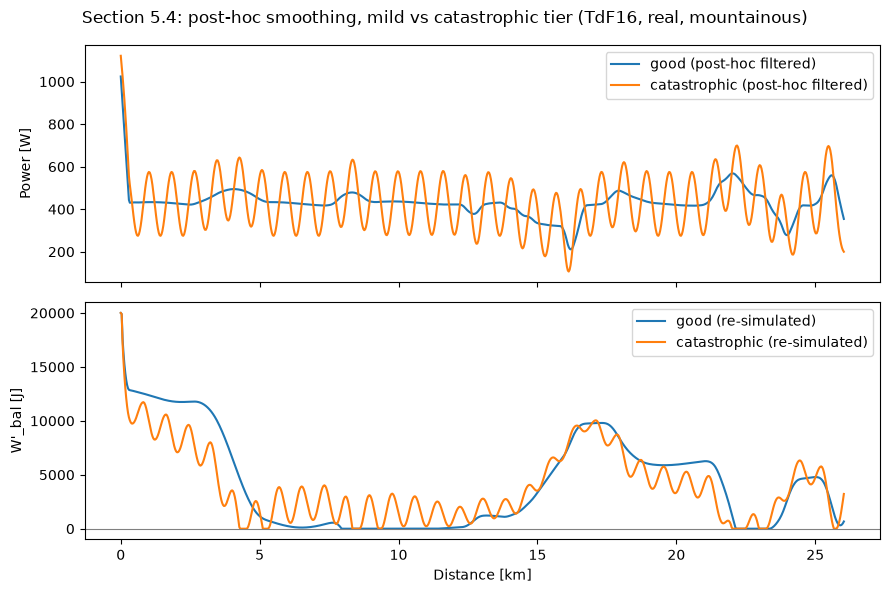

In [11]:
pc.plot_posthoc_extremes(res_hs_tdf16, tdf16_course, posthoc_results_tdf16, "Section 5.4: post-hoc smoothing, mild vs catastrophic tier (TdF16, real, mountainous)")

### 5.5 TARA 2026 Stage 3 (real, rolling/TTT)

Same 6 tiers, on `res_hs_tara` (rebuilt above), same `catastrophic_mode`
as 4.5 (`"sine"`).

In [12]:
posthoc_results_tara = pc.run_posthoc_tiers(pc.reference_rider, tara_course, pc.calm_wind, res_hs_tara, catastrophic_mode="sine", label="tara")

[tara] good         T= 42.7283 min  unsmoothed= 42.8427 min  delta= -6.864 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.139
[tara] acceptable   T= 42.7030 min  unsmoothed= 42.8427 min  delta= -8.385 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.101
[tara] borderline   T= 42.8808 min  unsmoothed= 42.8427 min  delta= +2.282 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.099
[tara] rough        T= 42.9487 min  unsmoothed= 42.8427 min  delta= +6.356 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.105
[tara] very_rough   T= 43.1830 min  unsmoothed= 42.8427 min  delta=+20.416 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.075
[tara] catastrophic T= 43.3584 min  unsmoothed= 42.8427 min  delta=+30.941 s   w_prime_violated=True   frac_of_course_at_W'=0: 0.070


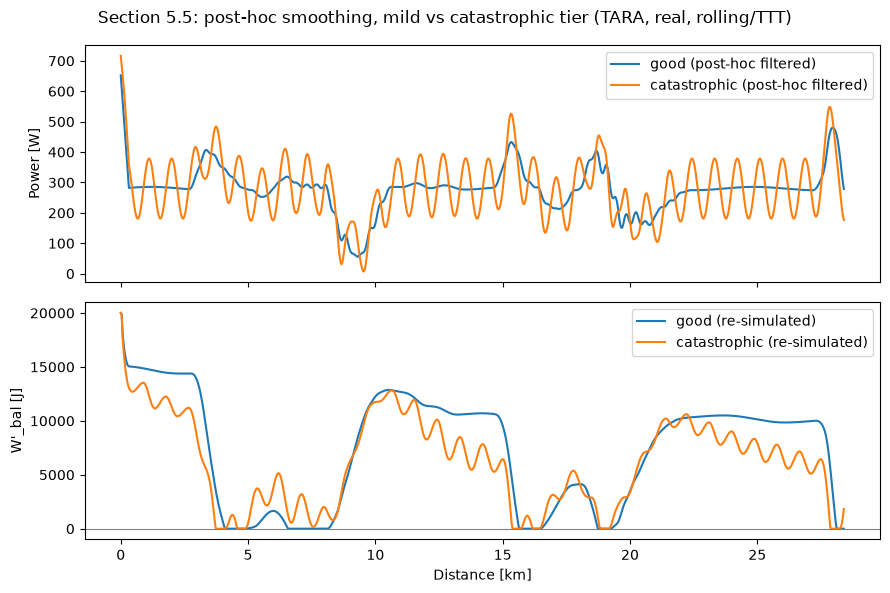

In [13]:
pc.plot_posthoc_extremes(res_hs_tara, tara_course, posthoc_results_tara, "Section 5.5: post-hoc smoothing, mild vs catastrophic tier (TARA, real, rolling/TTT)")

As in 5.1/5.2, every tier's baseline on all three real courses already
spends W' down to essentially zero by the finish (all five `res_hs_*`
results satisfy the same terminal-W'-near-zero property), so every tier
here is expected to flag `w_prime_violated=True` regardless of terrain --
the mechanism the "constrained re-optimization vs post-hoc smoothing"
comparison above describes is not specific to synthetic courses. Even the
mildest (`good`) tier already leaves a non-trivial fraction of the
re-simulated course sitting at the W'=0 floor (6.6-17.2% across the three
real courses).

The `catastrophic` tier's effect still varies far more by course than
tier severity alone would suggest: Giro10 ends up almost entirely floored
(97.1%) while TdF16 and TARA, despite a far rougher input, land at 6.1%
and 7.0%, below their own `good` tiers.

What is new since issue #5/#6 is that the *time* deltas on the two
rougher real courses now behave. TdF16 and TARA's `catastrophic` tiers
come back +20.7 s and +30.9 s slower than baseline, which is the sensible
direction for a heavily filtered plan, and their tier sequences are close
to monotonic in severity. Only Giro10 still shows a deeply negative delta
(-442.9 s), and it does so alongside a 97.1% floored fraction -- exactly
the combination 5.1 explains, where the reported time is an artifact of
the integrator's power floor rather than an achievable time. So the
non-monotonicity is now confined to the one course whose flag makes its
time meaningless, rather than being a general pattern.